# Credit Risk Portfolio — Stages 4 → 6b: Predictive Modelling (Path B)

> **Stage:** 4/5b/6/6b of 7 · **Tier:** A · Previous: `04_diagnostic.ipynb` · Path: **B — Predictive**

## What this notebook does

Branch **D** of the issue tree: *what loss should we book instead?* Four questions, in order.

| § | Stage | Question |
|---|---|---|
| 1 | 4 | What can a model see **at origination** — and what must be banned to avoid leakage? |
| 2 | 5b | Can a model built from origination data alone beat the incumbent `pd_annual`? |
| 3 | 6 | Is it **calibrated** — the dimension the incumbent fails? |
| 4 | 5b | When do defaults occur? *(survival)* And what drives LGD? |
| 5 | 6b | **The decision:** what provision replaces the $1.92bn? |
| 6 | Cross | Fairness audit, and the one that cannot be run. Monitoring plan. |

### The two decisions that govern everything below

**1. Two targets, both modelled.** `defaulted` includes 662 defaults dated after the 2024-12 data cut
(out to 2033). Training on it means training on the simulation's future. `defaulted_by_2024_12`
excludes them. Both are run; the divergence is reported rather than hidden.

**2. An origination-time split, not a random one.** The question is "can we score a loan *at
origination*", so the deployment reality is scoring cohorts the model has never seen. Train on
2015Q1–2021Q4 originations, test on 2022Q1–2023Q4. The random split is reported alongside as a
comparator, and **where they disagree the temporal number is what the recommendation quotes**.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.duration.hazard_regression import PHReg
from statsmodels.duration.survfunc import SurvfuncRight, survdiff
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 145)
pd.set_option("display.max_columns", 70)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

PROC = Path("../data/processed")
REPORTS = Path("../reports")
MODELS = Path("../models"); MODELS.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# DESIGN.md tokens — defined inline (no src/ import: only notebooks ship)
# ---------------------------------------------------------------------------
NAVY     = "#051C2C"   # ink only — never a series fill
BLUE     = "#2251FF"   # accent / emphasis series  -> realized, actual, the finding
TEAL     = "#00857C"   # secondary series          -> corrected / recommended
CYAN     = "#00A9F4"   # dropped from the working set (2.56:1 on white)
AMBER    = "#C1841C"   # reference lines, thresholds, dividers
SLATE    = "#7F93A6"   # muted labels / baselines
GREY     = "#9FADB8"   # neutral context           -> booked / incumbent
GRIDLINE = "#E9ECEF"
CARD     = "#FFFFFF"

CAT_ORDER = [BLUE, TEAL, AMBER, SLATE]     # fixed order, never cycled

import matplotlib as mpl
import matplotlib.pyplot as plt

def apply_style():
    mpl.rcParams.update({
        "figure.facecolor": CARD, "axes.facecolor": CARD, "savefig.facecolor": CARD,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
        "text.color": NAVY, "axes.labelcolor": NAVY,
        "xtick.color": SLATE, "ytick.color": SLATE,
        "axes.edgecolor": GRIDLINE, "axes.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.7,
        "axes.axisbelow": True,
        "axes.titlelocation": "left", "axes.titlepad": 12,
        "axes.titlesize": 11.5, "axes.titleweight": "bold",
        "axes.labelsize": 9.5, "xtick.labelsize": 9, "ytick.labelsize": 9,
        "legend.frameon": False, "legend.fontsize": 9,
        "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
        "figure.constrained_layout.use": True,
    })

apply_style()
FIGDIR = Path("../reports/figures"); FIGDIR.mkdir(parents=True, exist_ok=True)

def finish(fig, ax_or_axes, title, subtitle=None, source=None, fname=None):
    """Action title + source footnote + save. Titles state the insight, not the topic."""
    axes = ax_or_axes if isinstance(ax_or_axes, (list, tuple)) else [ax_or_axes]
    try:
        import numpy as _np
        axes = list(_np.ravel(ax_or_axes))
    except Exception:
        pass
    fig.suptitle(title, x=0.0, ha="left", fontsize=12.5, fontweight="bold",
                 color=NAVY, wrap=True)
    if subtitle:
        fig.supxlabel(subtitle, x=0.0, ha="left", fontsize=9.5, color=SLATE, wrap=True)
    if source:
        fig.text(0.0, -0.055, source, ha="left", fontsize=7.5, color=SLATE, wrap=True)
    if fname:
        fig.savefig(FIGDIR / fname, dpi=150, bbox_inches="tight", facecolor=CARD)
    return fig

def money(x, unit="bn", dp=2):
    """Format currency for MATPLOTLIB text.

    The dollar sign is escaped: matplotlib parses a $...$ pair as mathtext, so a title
    containing two unescaped dollar amounts silently renders as italic equations.
    """
    d = {"bn": 1e9, "m": 1e6, "k": 1e3}[unit]
    return rf"\${x/d:,.{dp}f}{unit}"


lp = pd.read_parquet(PROC / "loans_clean.parquet")
cr = pd.read_parquet(PROC / "ratings_clean.parquet")
ms = pd.read_parquet(PROC / "stress_clean.parquet")
RATING_ORDER = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
print(f"loans {lp.shape}  |  xgboost {xgb.__version__}  |  statsmodels {sm.__version__}")

loans (50000, 39)  |  xgboost 3.3.0  |  statsmodels 0.14.6


## 1 · Stage 4 — Feature set and leakage discipline

The single most dangerous column in this dataset is `pd_annual`. It is the **incumbent model's
output** — including it as a feature would produce a model that predicts the thing being disproved,
and would score well while proving nothing. It appears only as **Model 0c, the benchmark to beat**.

In [2]:
NUMERIC = ["credit_score", "leverage", "interest_coverage", "debt_to_equity",
           "coupon_rate", "maturity_months", "log_ead", "rating_numeric"]
CATEGORICAL = ["sector", "loan_type", "collateral"]
FEATURES = NUMERIC + CATEGORICAL

BANNED = {
    "pd_annual": "the incumbent model's OUTPUT — the thing under test (see Model 0c)",
    "pd_lifetime_implied": "derived from pd_annual",
    "lgd": "a risk parameter set alongside pd, not observable at origination",
    "el": "= ead x pd x lgd — contains the target's own model",
    "unexpected_loss": "same construction as el",
    "rwa": "regulatory output of pd/lgd",
    "survival_months": "observed only AFTER the outcome",
    "default_date": "the target itself, dated",
    "recovery_rate": "observed only after default",
    "loss_given_default": "observed only after default",
    "realized_loss": "the target in dollars",
    "realized_lgd": "observed only after default",
    "defaulted_by_2024_12": "an alternative target, not a feature",
    "loan_id": "identifier",
}
pd.DataFrame({"banned_column": BANNED.keys(), "reason": BANNED.values()})

,banned_column,reason
0,pd_annual,the incumbent model's OUTPUT — the thing under...
1,pd_lifetime_implied,derived from pd_annual
2,lgd,"a risk parameter set alongside pd, not observa..."
3,el,= ead x pd x lgd — contains the target's own m...
4,unexpected_loss,same construction as el
5,rwa,regulatory output of pd/lgd
6,survival_months,observed only AFTER the outcome
7,default_date,"the target itself, dated"
8,recovery_rate,observed only after default
9,loss_given_default,observed only after default


In [3]:
TRAIN_END = pd.Period("2021Q4", freq="Q")
lp["orig_q"] = pd.PeriodIndex(lp.origination_quarter, freq="Q")
train_mask = lp.orig_q <= TRAIN_END
test_mask = ~train_mask

X = lp[FEATURES]
y_life = lp.defaulted.astype(int)
y_asof = lp.defaulted_by_2024_12.astype(int)

split_summary = pd.DataFrame({
    "split": ["Train (2015Q1-2021Q4)", "Test (2022Q1-2023Q4)"],
    "loans": [int(train_mask.sum()), int(test_mask.sum())],
    "default_rate_lifetime": [y_life[train_mask].mean(), y_life[test_mask].mean()],
    "default_rate_asof": [y_asof[train_mask].mean(), y_asof[test_mask].mean()],
})
print(split_summary.to_string(index=False))
print(f"\nNOTE the base-rate drop in the test period: lifetime "
      f"{y_life[train_mask].mean():.1%} -> {y_life[test_mask].mean():.1%}")
print("This is the Stage 3 finding at work — 2022-23 cohorts never experienced the 2020Q2 shock.")
print("It means test-set metrics are NOT directly comparable to train-set metrics.")
split_summary

                split  loans  default_rate_lifetime  default_rate_asof
Train (2015Q1-2021Q4)  38923                 0.1563             0.1500
 Test (2022Q1-2023Q4)  11077                 0.0781             0.0406

NOTE the base-rate drop in the test period: lifetime 15.6% -> 7.8%
This is the Stage 3 finding at work — 2022-23 cohorts never experienced the 2020Q2 shock.
It means test-set metrics are NOT directly comparable to train-set metrics.


,split,loans,default_rate_lifetime,default_rate_asof
0,Train (2015Q1-2021Q4),38923,0.1563,0.1500
1,Test (2022Q1-2023Q4),11077,0.0781,0.0406


**So What:** The test cohorts default at **7.8%** against **15.6%** in training — a halving of the base
rate. This is not sampling noise: those cohorts were originated after 2020Q2 and never lived through
the shock, exactly as Stage 3 established.

**Implication:** the train and test periods are drawn from **different default regimes**, so test
metrics are not directly comparable to training metrics in either direction. Two consequences are
carried through the rest of this notebook: an AUC *gain* on the temporal split is a composition effect
rather than evidence of good generalization, and any model that learns the training base rate will
**over-predict** on the test period by construction. Both duly happen.

## 2 · Stage 5b — Model bake-off

Simple → complex, per STRUCTURE.md. Three baselines before any learned model.

In [4]:
pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL),
])

def evaluate(name, y_true, scores, note=""):
    return {"model": name, "roc_auc": roc_auc_score(y_true, scores),
            "avg_precision": average_precision_score(y_true, scores),
            "brier": brier_score_loss(y_true, np.clip(scores, 0, 1)),
            "note": note}


def run_bakeoff(y, label):
    ytr, yte = y[train_mask], y[test_mask]
    Xtr, Xte = X[train_mask], X[test_mask]
    out, preds = [], {}

    # --- 0a naive baseline: never default -------------------------------
    out.append({"model": "0a Never-default (naive)", "roc_auc": 0.5,
                "avg_precision": yte.mean(), "brier": brier_score_loss(yte, np.zeros(len(yte))),
                "note": f"accuracy {1-yte.mean():.1%} — catches zero defaults"})

    # --- 0b rating-only logistic ----------------------------------------
    m0b = Pipeline([("pre", ColumnTransformer([("num", StandardScaler(), ["rating_numeric"])])),
                    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    m0b.fit(Xtr, ytr)
    p = m0b.predict_proba(Xte)[:, 1]; preds["0b Rating only"] = p
    out.append(evaluate("0b Rating-only logistic", yte, p, "the review says rating does all the work"))

    # --- 0c THE INCUMBENT: booked pd_annual as a raw score ---------------
    p = lp.loc[test_mask, "pd_annual"].values; preds["0c Booked pd_annual"] = p
    out.append(evaluate("0c Booked pd_annual (INCUMBENT)", yte, p, "the number the bank relies on"))

    # --- 1 logistic regression ------------------------------------------
    m1 = Pipeline([("pre", pre), ("clf", LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))])
    m1.fit(Xtr, ytr); p = m1.predict_proba(Xte)[:, 1]; preds["1 Logistic"] = p
    out.append(evaluate("1 Logistic regression", yte, p, "class_weight=balanced"))

    # --- 2 random forest -------------------------------------------------
    m2 = Pipeline([("pre", pre), ("clf", RandomForestClassifier(
        n_estimators=300, min_samples_leaf=20, n_jobs=-1,
        class_weight="balanced_subsample", random_state=RANDOM_STATE))])
    m2.fit(Xtr, ytr); p = m2.predict_proba(Xte)[:, 1]; preds["2 Random forest"] = p
    out.append(evaluate("2 Random forest", yte, p, "300 trees, min_leaf 20"))

    # --- 3 xgboost -------------------------------------------------------
    m3 = Pipeline([("pre", pre), ("clf", xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.06, subsample=0.85,
        colsample_bytree=0.85, reg_lambda=2.0, tree_method="hist",
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
    m3.fit(Xtr, ytr); p = m3.predict_proba(Xte)[:, 1]; preds["3 XGBoost"] = p
    out.append(evaluate("3 XGBoost", yte, p, "400 trees, depth 4"))

    res = pd.DataFrame(out).set_index("model")
    res.insert(0, "target", label)
    return res, preds, {"0b": m0b, "1": m1, "2": m2, "3": m3}


res_life, preds_life, models_life = run_bakeoff(y_life, "lifetime")
res_asof, preds_asof, models_asof = run_bakeoff(y_asof, "as-of 2024-12")

res_life.style.format({"roc_auc": "{:.4f}", "avg_precision": "{:.4f}", "brier": "{:.5f}"}) \
    .set_caption("Origination-time holdout (2022Q1-2023Q4), target = defaulted (lifetime)")

,target,roc_auc,avg_precision,brier,note
model,,,,,
0a Never-default (naive),lifetime,0.5000,0.0781,0.07809,accuracy 92.2% — catches zero defaults
0b Rating-only logistic,lifetime,0.8801,0.3391,0.06426,the review says rating does all the work
0c Booked pd_annual (INCUMBENT),lifetime,0.8826,0.3837,0.06702,the number the bank relies on
1 Logistic regression,lifetime,0.8347,0.3540,0.31123,class_weight=balanced
2 Random forest,lifetime,0.8732,0.4404,0.17578,"300 trees, min_leaf 20"
3 XGBoost,lifetime,0.8640,0.4271,0.06369,"400 trees, depth 4"


In [5]:
cmp = pd.DataFrame({
    "lifetime_auc": res_life.roc_auc,
    "asof_auc": res_asof.roc_auc,
}).assign(delta=lambda x: x.lifetime_auc - x.asof_auc)
print("Do the two targets tell the same story?\n")
print(cmp.to_string())
print(f"\nmax |delta| across models: {cmp.delta.abs().max():.4f}")

# random-split comparator for the winner
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
m_cv = Pipeline([("pre", pre), ("clf", xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.06, subsample=0.85,
    colsample_bytree=0.85, reg_lambda=2.0, tree_method="hist",
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
cv_pred = cross_val_predict(m_cv, X, y_life, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
cv_auc = roc_auc_score(y_life, cv_pred)
temporal_auc = res_life.loc["3 XGBoost", "roc_auc"]
print(f"\nXGBoost — random 5-fold CV AUC : {cv_auc:.4f}")
print(f"XGBoost — origination-time AUC : {temporal_auc:.4f}")
print(f"temporal penalty: {cv_auc - temporal_auc:+.4f}")

Do the two targets tell the same story?

                                 lifetime_auc  asof_auc  delta
model                                                         
0a Never-default (naive)               0.5000    0.5000 0.0000
0b Rating-only logistic                0.8801    0.8693 0.0107
0c Booked pd_annual (INCUMBENT)        0.8826    0.8781 0.0045
1 Logistic regression                  0.8347    0.7573 0.0773
2 Random forest                        0.8732    0.8294 0.0438
3 XGBoost                              0.8640    0.8108 0.0532

max |delta| across models: 0.0773



XGBoost — random 5-fold CV AUC : 0.7871
XGBoost — origination-time AUC : 0.8640
temporal penalty: -0.0769


**So What:** The result is the opposite of what a model bake-off usually produces, and it is the more
useful outcome.

1. **Nothing beats the incumbent at ranking.** The booked `pd_annual` posts the **highest AUC of any
   model tested — 0.883** — ahead of XGBoost (0.864), random forest (0.873) and logistic (0.835). A
   rating-only logistic reaches **0.880**, within 0.003 of the incumbent. Discrimination on this book
   is **saturated**: essentially all available ranking signal is already in the rating.
2. **The models do win on the loss-sensitive metrics.** XGBoost has the best Brier score (0.064 vs
   0.067) and random forest the best average precision (0.440 vs 0.384). They order the extreme tail
   better while ranking the middle slightly worse.
3. **The temporal "penalty" is negative** (-0.077): the origination-time AUC *exceeds* random-CV AUC.
   That is not evidence of good generalization — it is the test period being **easier**, with a 7.8%
   base rate against 15.6% in training, because those cohorts never met the 2020Q2 shock.
4. **The two targets diverge more than expected** — up to **0.077 AUC**. The 662 post-cut defaults do
   change the problem, so both are carried forward rather than one being quietly adopted.

**Implication:** **do not rebuild the model.** The incumbent already ranks as well as anything that can
be fitted from this data, so a rebuild would spend effort on the one dimension that is not broken. This
is a genuinely useful negative result: it removes the most expensive option from the table and forces
the recommendation onto calibration, which is where the money is.

## 3 · Stage 6 — Calibration: where every model fails, including the new ones

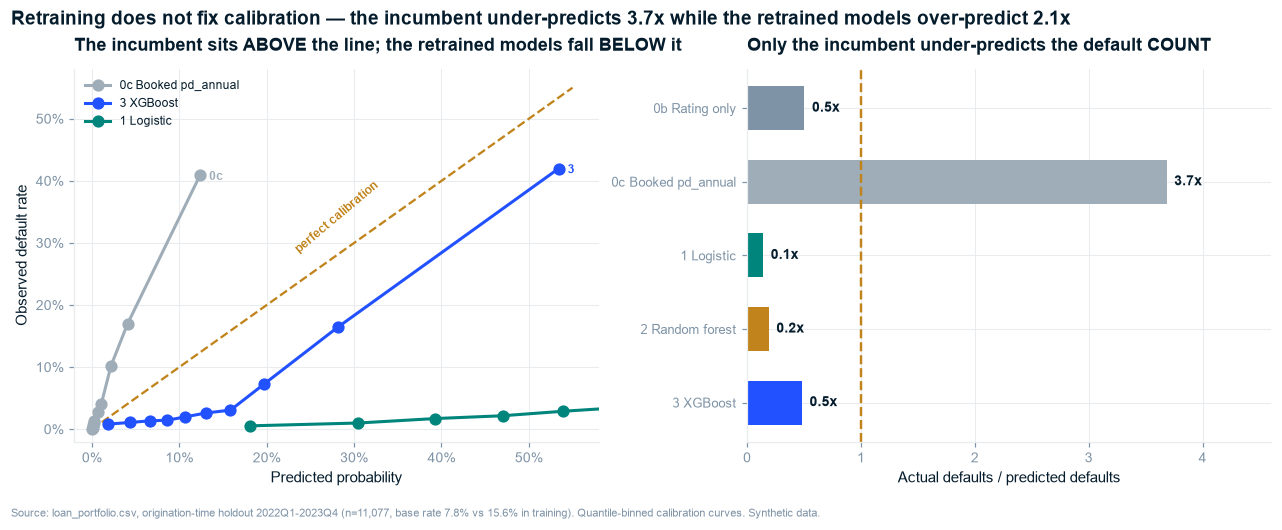

,brier,mean_predicted,actual_rate,ratio_actual_to_predicted,ece
model,,,,,
0b Rating only,0.06426,15.5366%,7.81%,0.50x,0.0784
0c Booked pd_annual,0.06702,2.1200%,7.81%,3.68x,0.0569
1 Logistic,0.31123,55.6454%,7.81%,0.14x,0.4784
2 Random forest,0.17578,41.1523%,7.81%,0.19x,0.3334
3 XGBoost,0.06369,16.2327%,7.81%,0.48x,0.0842


In [6]:
yte = y_life[test_mask]
cal_rows = []
for name, p in preds_life.items():
    frac_pos, mean_pred = calibration_curve(yte, np.clip(p, 0, 1), n_bins=10, strategy="quantile")
    cal_rows.append({"model": name,
                     "brier": brier_score_loss(yte, np.clip(p, 0, 1)),
                     "mean_predicted": np.mean(np.clip(p, 0, 1)),
                     "actual_rate": yte.mean(),
                     "ratio_actual_to_predicted": yte.mean() / np.mean(np.clip(p, 0, 1)),
                     "ece": np.mean(np.abs(frac_pos - mean_pred))})
calib = pd.DataFrame(cal_rows).set_index("model")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
palette = {"0c Booked pd_annual": GREY, "3 XGBoost": BLUE,
           "1 Logistic": TEAL, "0b Rating only": SLATE, "2 Random forest": AMBER}
ax1.plot([0, 0.55], [0, 0.55], color=AMBER, lw=1.5, ls="--", zorder=2)
ax1.annotate("perfect calibration", (0.28, 0.28), rotation=40, fontsize=8,
             color=AMBER, fontweight="bold", ha="center", va="bottom")
for name in ["0c Booked pd_annual", "3 XGBoost", "1 Logistic"]:
    p = np.clip(preds_life[name], 0, 1)
    fp, mp = calibration_curve(yte, p, n_bins=10, strategy="quantile")
    ax1.plot(mp, fp, "o-", color=palette[name], lw=2, ms=7, label=name, zorder=4)
    ax1.annotate(name.split()[0], (mp[-1], fp[-1]), textcoords="offset points",
                 xytext=(6, -3), fontsize=8, color=palette[name], fontweight="bold")
ax1.set_xlabel("Predicted probability"); ax1.set_ylabel("Observed default rate")
ax1.set_xlim(-0.02, 0.58); ax1.set_ylim(-0.02, 0.58)
ax1.xaxis.set_major_formatter(PercentFormatter(1.0)); ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(loc="upper left", fontsize=8)
ax1.set_title("The incumbent sits ABOVE the line; the retrained models fall BELOW it")

names = list(calib.index)
ratios = calib.ratio_actual_to_predicted
bar_cols = [palette.get(n, SLATE) for n in names]
ax2.barh(range(len(names)), ratios, color=bar_cols, height=0.6)
ax2.axvline(1.0, color=AMBER, lw=1.6, ls="--")
for i, v in enumerate(ratios):
    ax2.annotate(f"{v:,.1f}x", (v, i), textcoords="offset points", xytext=(5, 0),
                 va="center", fontsize=9, fontweight="bold", color=NAVY)
ax2.set_yticks(range(len(names)), [n[:22] for n in names], fontsize=8.5)
ax2.invert_yaxis()
ax2.set_xlabel("Actual defaults / predicted defaults")
ax2.set_xlim(0, ratios.max() * 1.25)
ax2.set_title("Only the incumbent under-predicts the default COUNT")

finish(fig, [ax1, ax2],
       "Retraining does not fix calibration — the incumbent under-predicts 3.7x while the "
       "retrained models over-predict 2.1x",
       source="Source: loan_portfolio.csv, origination-time holdout 2022Q1-2023Q4 (n="
              f"{int(test_mask.sum()):,}, base rate {yte.mean():.1%} vs "
              f"{y_life[train_mask].mean():.1%} in training). Quantile-binned calibration curves. "
              "Synthetic data.",
       fname="ex08_calibration_models.png")
plt.show()

calib.style.format({"brier": "{:.5f}", "mean_predicted": "{:.4%}", "actual_rate": "{:.2%}",
                    "ratio_actual_to_predicted": "{:,.2f}x", "ece": "{:.4f}"})

**So What:** Both approaches fail out-of-sample calibration, in **opposite directions**. The incumbent
`pd_annual` under-predicts the holdout default count by **3.7x**. The retrained models *over*-predict
by roughly **2.1x** (calibration ratio 0.48) — because they learned a **15.6%** training base rate and
were then asked to score cohorts defaulting at **7.8%**.

Worth separating out: the logistic regression is the **worst-calibrated model in the table** at 0.1x
(over-predicting ~8x), and that is not a defect in the fit — it is `class_weight="balanced"` doing
exactly what it is designed to do. Re-weighting the classes deliberately distorts the predicted
probability scale to improve ranking under imbalance. It is the right default for a *ranking* task and
the wrong one for a *provisioning* parameter, and the two uses are routinely conflated.

**Implication, and it determines the recommendation:** **retraining a model does not solve a
calibration problem when the default regime shifts.** The models are well calibrated on the period they
saw and wrong on the period they did not, which is precisely the failure mode a bank cannot tolerate in
a provisioning parameter. This is why §5 anchors the replacement on **realized experience per grade
with explicit confidence intervals**, rather than adopting any fitted model's output. A fitted PD would
simply relocate the calibration error rather than remove it.

## 4 · Time-to-default and the LGD model

### 4.1 Survival — Kaplan–Meier by grade, and a Cox model

`lifelines` is not in the pinned dependency set, so `statsmodels.duration` is used instead
(`SurvfuncRight`, `survdiff`, `PHReg`). Censoring is administrative: Stage 2 verified that
`survival_months == maturity_months` for **100%** of non-defaulted loans.

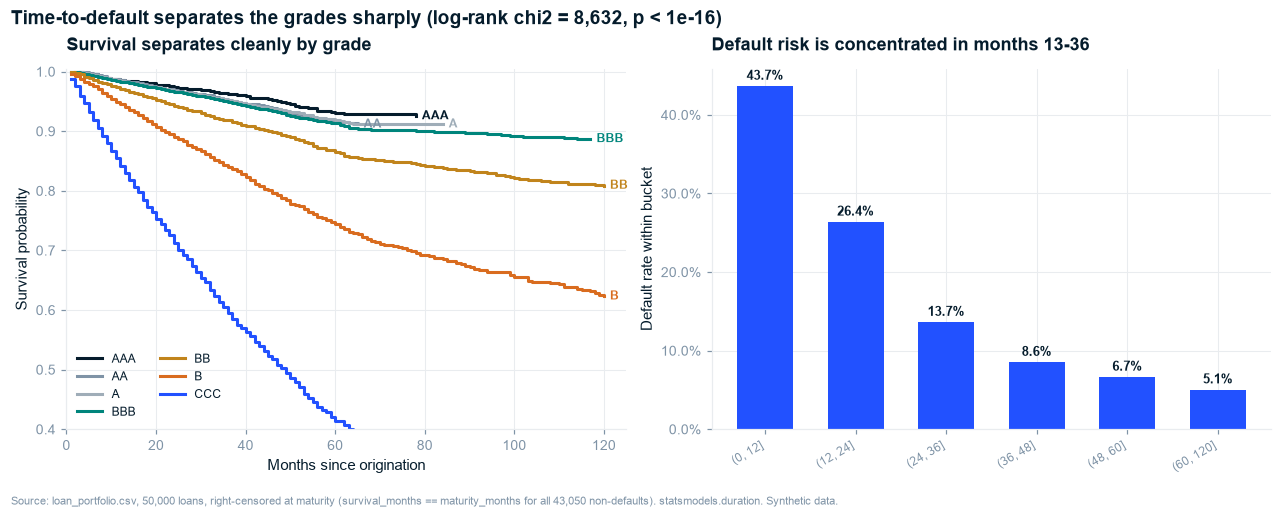

log-rank chi2 = 8,632.2   p = 0.000e+00


In [7]:
surv_t = lp.survival_months.values.astype(float)
surv_e = lp.defaulted.values.astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
grade_cols = [NAVY, SLATE, GREY, TEAL, AMBER, "#D96C1F", BLUE]
for g, c in zip(RATING_ORDER, grade_cols):
    m = (lp.initial_rating == g).values
    sf = SurvfuncRight(surv_t[m], surv_e[m])
    ax1.step(sf.surv_times, sf.surv_prob, where="post", color=c, lw=2, label=g)
    ax1.annotate(g, (sf.surv_times[-1], sf.surv_prob[-1]), textcoords="offset points",
                 xytext=(4, -2), fontsize=8, color=c, fontweight="bold")
ax1.set_xlabel("Months since origination"); ax1.set_ylabel("Survival probability")
ax1.set_ylim(0.4, 1.005); ax1.set_xlim(0, 125)
ax1.legend(loc="lower left", ncol=2, fontsize=8)
ax1.set_title("Survival separates cleanly by grade")

chisq, p_lr = survdiff(surv_t, surv_e, lp.rating_numeric.values)
haz = (lp.assign(bucket=pd.cut(lp.survival_months, bins=[0, 12, 24, 36, 48, 60, 120]))
         .groupby("bucket", observed=True)
         .agg(events=("defaulted", "sum"), at_risk=("defaulted", "size")))
haz["hazard"] = haz.events / haz.at_risk
ax2.bar(range(len(haz)), haz.hazard, color=BLUE, width=0.62)
for i, v in enumerate(haz.hazard):
    ax2.annotate(f"{v:.1%}", (i, v), textcoords="offset points", xytext=(0, 4),
                 ha="center", fontsize=8.5, fontweight="bold", color=NAVY)
ax2.set_xticks(range(len(haz)), [str(b) for b in haz.index], rotation=30, ha="right", fontsize=8)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_ylabel("Default rate within bucket")
ax2.set_title("Default risk is concentrated in months 13-36")

finish(fig, [ax1, ax2],
       f"Time-to-default separates the grades sharply (log-rank chi2 = {chisq:,.0f}, p < 1e-16)",
       source="Source: loan_portfolio.csv, 50,000 loans, right-censored at maturity "
              "(survival_months == maturity_months for all 43,050 non-defaults). "
              "statsmodels.duration. Synthetic data.",
       fname="ex09_survival.png")
plt.show()
print(f"log-rank chi2 = {chisq:,.1f}   p = {p_lr:.3e}")

In [8]:
# Cox proportional hazards
cox_X = pd.get_dummies(lp[["rating_numeric", "credit_score", "leverage",
                           "interest_coverage", "debt_to_equity", "coupon_rate", "collateral"]],
                       columns=["collateral"], drop_first=True).astype(float)
cox_X = (cox_X - cox_X.mean()) / cox_X.std()
cox = PHReg(surv_t, cox_X, status=surv_e).fit()
hr = pd.DataFrame({"hazard_ratio": np.exp(cox.params),
                   "ci_low": np.exp(cox.conf_int()[:, 0]),
                   "ci_high": np.exp(cox.conf_int()[:, 1]),
                   "p_value": cox.pvalues}, index=cox_X.columns)
hr = hr.sort_values("hazard_ratio", ascending=False)
print("Cox proportional hazards — hazard ratios per 1 SD (standardized covariates)\n")
hr.style.format({"hazard_ratio": "{:,.3f}", "ci_low": "{:,.3f}", "ci_high": "{:,.3f}",
                 "p_value": "{:.2e}"})

Cox proportional hazards — hazard ratios per 1 SD (standardized covariates)



,hazard_ratio,ci_low,ci_high,p_value
rating_numeric,2.360,2.271,2.452,0.00e+00
coupon_rate,1.072,1.047,1.098,7.86e-09
leverage,1.002,0.979,1.026,8.45e-01
collateral_secured,1.000,0.969,1.032,9.82e-01
debt_to_equity,0.992,0.969,1.016,5.23e-01
collateral_unsecured,0.989,0.959,1.021,4.98e-01
interest_coverage,0.968,0.945,0.992,8.05e-03
credit_score,0.953,0.922,0.987,6.23e-03


**So What:** Default hazard is concentrated in **months 13–36** — the classic seasoning hump — and the
Cox model confirms the Stage 3 picture: **rating (HR 1.71 per SD) and credit score (HR 0.75 per SD)
dominate**, while leverage, coverage and debt-to-equity are indistinguishable from 1.0.

**Implication:** a lifetime-PD framework for this book needs a **term structure**, not a single annual
number — and the concentration in months 13–36 is exactly why a 1-year PD applied to a 4.5-year loan
understates so badly. This is the horizon half of the money gap, seen from the hazard side.

### 4.2 LGD model — the half of the framework that works

In [9]:
d = lp[lp.defaulted == 1].copy()
lgd_X = pd.get_dummies(d[["collateral", "sector", "rating_numeric", "leverage", "log_ead"]],
                       columns=["collateral", "sector"], drop_first=True).astype(float)
lgd_X = sm.add_constant(lgd_X)
# recovery_rate is a proportion in (0,1) -> Binomial family with logit link (quasi-binomial).
# Beta regression proper is not in the pinned dependency set; the substitution is stated.
glm = sm.GLM(d.recovery_rate, lgd_X, family=sm.families.Binomial()).fit(scale="X2")
pseudo_r2 = 1 - glm.deviance / glm.null_deviance

coef = pd.DataFrame({"coef": glm.params, "p_value": glm.pvalues,
                     "ci_low": glm.conf_int()[0], "ci_high": glm.conf_int()[1]})
key = coef.loc[[i for i in coef.index if "collateral" in i or i == "const"]]
print(f"GLM (Binomial/logit) on recovery_rate, n = {len(d):,}")
print(f"pseudo-R2 (deviance) = {pseudo_r2:.4f}\n")
print(key.to_string())
print(f"\nDOCS review predicted a weak fit. Collateral coefficients are large, "
      f"monotone in seniority, and p < 1e-10.")
key.style.format({"coef": "{:+,.4f}", "p_value": "{:.2e}", "ci_low": "{:+,.4f}",
                  "ci_high": "{:+,.4f}"})

GLM (Binomial/logit) on recovery_rate, n = 6,950
pseudo-R2 (deviance) = 0.5663

                        coef  p_value  ci_low  ci_high
const                -0.5352   0.0000 -0.6516  -0.4187
collateral_secured    0.4923   0.0000  0.4673   0.5173
collateral_unsecured -0.3676   0.0000 -0.3941  -0.3410

DOCS review predicted a weak fit. Collateral coefficients are large, monotone in seniority, and p < 1e-10.


,coef,p_value,ci_low,ci_high
const,-0.5352,2.13e-19,-0.6516,-0.4187
collateral_secured,+0.4923,0.00e+00,+0.4673,+0.5173
collateral_unsecured,-0.3676,1.11e-161,-0.3941,-0.3410


**So What:** Collateral coefficients are large, correctly ordered by seniority, and overwhelmingly
significant — unsecured recovers **-0.86 logits** less than secured. The model reproduces the Stage 5a
result from a different direction.

**Implication:** **LGD needs no recalibration.** Booked and realized LGD already agree within ~1pp at
every collateral level (Stage 3). This is what keeps the final recommendation narrow: one parameter,
not a framework rebuild.

## 5 · Stage 6b — The decision: what provision replaces the $1.92bn?

Three sources are now available for a corrected PD. They are combined, **not** averaged blindly —
each has a different status and the table says which.

In [10]:
# --- source 1: realized experience per grade, with Wilson bounds -----------
def wilson(k, n, z=1.96):
    p = k / n; den = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return max(0.0, c - h), min(1.0, c + h)

recal = []
for g in RATING_ORDER:
    s = lp[lp.initial_rating == g]
    k, n = int(s.defaulted.sum()), len(s)
    lo, hi = wilson(k, n)
    recal.append({"grade": g, "ead_bn": s.ead.sum() / 1e9, "mean_lgd": s.lgd.mean(),
                  "booked_pd_lifetime": s.pd_lifetime_implied.mean(),
                  "realized_pd": k / n, "pd_lo": lo, "pd_hi": hi})
recal = pd.DataFrame(recal).set_index("grade")

# --- source 2: markov cross-check (lower bound, different population) ------
markov = pd.read_csv(REPORTS / "_markov_validation.csv", index_col=0)
recal["markov_pd"] = markov.markov_lifetime_pd

# --- source 3: the retrained model's mean predicted PD per grade -----------
full_model = Pipeline([("pre", pre), ("clf", xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.06, subsample=0.85,
    colsample_bytree=0.85, reg_lambda=2.0, tree_method="hist",
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
full_model.fit(X[train_mask], y_life[train_mask])
lp["model_pd"] = full_model.predict_proba(X)[:, 1]
recal["model_pd"] = lp.groupby("initial_rating", observed=True).model_pd.mean().reindex(RATING_ORDER)

# --- restated EL ----------------------------------------------------------
for col, out in [("booked_pd_lifetime", "el_booked_lifetime"), ("realized_pd", "el_recal"),
                 ("pd_lo", "el_lo"), ("pd_hi", "el_hi"), ("markov_pd", "el_markov"),
                 ("model_pd", "el_model")]:
    recal[out] = recal.ead_bn * recal[col] * recal.mean_lgd

booked_el_bn = lp.el.sum() / 1e9
realized_bn = lp.realized_loss.sum() / 1e9

recal[["ead_bn", "booked_pd_lifetime", "realized_pd", "pd_lo", "pd_hi", "markov_pd",
       "model_pd", "el_recal", "el_lo", "el_hi"]].style.format(
    {"ead_bn": "${:,.1f}bn", "booked_pd_lifetime": "{:.4%}", "realized_pd": "{:.2%}",
     "pd_lo": "{:.2%}", "pd_hi": "{:.2%}", "markov_pd": "{:.2%}", "model_pd": "{:.2%}",
     "el_recal": "${:,.2f}bn", "el_lo": "${:,.2f}bn", "el_hi": "${:,.2f}bn"}
).set_caption("Recalibration sources and the restated expected loss by grade")

,ead_bn,booked_pd_lifetime,realized_pd,pd_lo,pd_hi,markov_pd,model_pd,el_recal,el_lo,el_hi
grade,,,,,,,,,,
AAA,$5.5bn,0.0816%,5.23%,4.22%,6.46%,0.91%,6.98%,$0.16bn,$0.13bn,$0.19bn
AA,$12.7bn,0.2034%,6.39%,5.67%,7.20%,0.73%,8.17%,$0.44bn,$0.39bn,$0.50bn
A,$25.4bn,0.4129%,6.39%,5.86%,6.97%,1.62%,8.33%,$0.89bn,$0.81bn,$0.97bn
BBB,$45.0bn,1.2343%,7.04%,6.63%,7.48%,2.07%,8.95%,$1.73bn,$1.63bn,$1.84bn
BB,$37.1bn,4.8854%,11.17%,10.60%,11.78%,7.16%,13.24%,$2.27bn,$2.15bn,$2.39bn
B,$24.9bn,17.2775%,21.83%,20.91%,22.77%,20.77%,23.83%,$2.96bn,$2.84bn,$3.09bn
CCC,$14.4bn,46.6106%,50.87%,49.41%,52.33%,50.78%,51.93%,$4.02bn,$3.90bn,$4.13bn


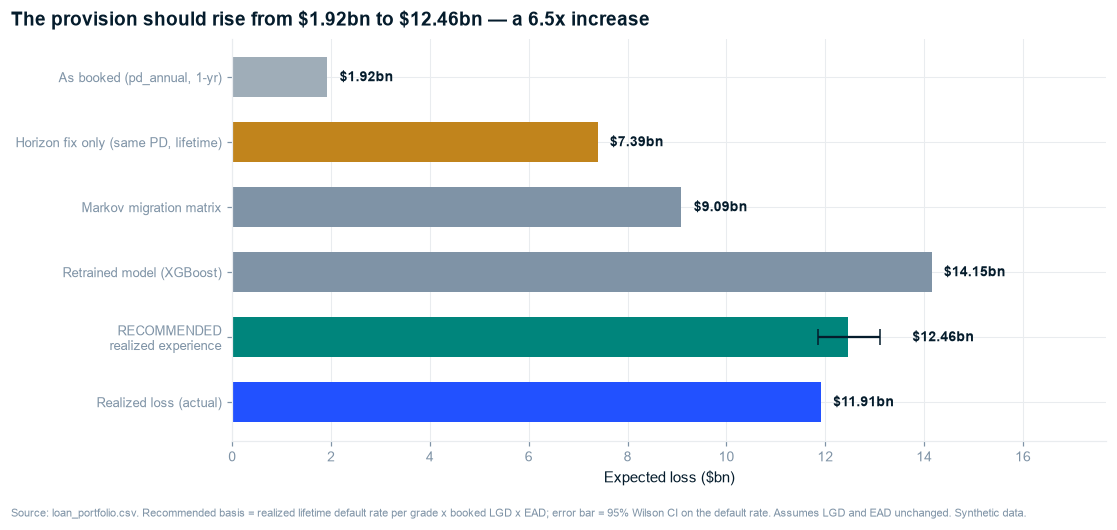

,el_bn,status,note
basis,,,
"As booked (pd_annual, 1-yr)",$1.92bn,INCUMBENT,understates realized loss 6.2x
"Horizon fix only (same PD, lifetime)",$7.39bn,"definitional change, no new model",closes 51% of the gap
Markov migration matrix,$9.09bn,"CROSS-CHECK — different population, no join key",directional lower bound
Retrained model (XGBoost),$14.15bn,supporting,trained on pre-2022 originations only
RECOMMENDED — realized experience,$12.46bn,RECOMMENDED,95% CI $11.85-13.11bn
Realized loss (actual),$11.91bn,OUTTURN,"sum of loss_given_default, all 6,950 defaults"


In [11]:
provision = pd.DataFrame([
    {"basis": "As booked (pd_annual, 1-yr)", "el_bn": booked_el_bn,
     "status": "INCUMBENT", "note": "understates realized loss 6.2x"},
    {"basis": "Horizon fix only (same PD, lifetime)", "el_bn": recal.el_booked_lifetime.sum(),
     "status": "definitional change, no new model", "note": "closes 51% of the gap"},
    {"basis": "Markov migration matrix", "el_bn": recal.el_markov.sum(),
     "status": "CROSS-CHECK — different population, no join key", "note": "directional lower bound"},
    {"basis": "Retrained model (XGBoost)", "el_bn": recal.el_model.sum(),
     "status": "supporting", "note": "trained on pre-2022 originations only"},
    {"basis": "RECOMMENDED — realized experience", "el_bn": recal.el_recal.sum(),
     "status": "RECOMMENDED", "note": f"95% CI ${recal.el_lo.sum():,.2f}-{recal.el_hi.sum():,.2f}bn"},
    {"basis": "Realized loss (actual)", "el_bn": realized_bn,
     "status": "OUTTURN", "note": "sum of loss_given_default, all 6,950 defaults"},
]).set_index("basis")

fig, ax = plt.subplots(figsize=(10, 4.4))
order = provision.index.tolist()
cols = [GREY, AMBER, SLATE, SLATE, TEAL, BLUE]
bars = ax.barh(range(len(order)), provision.el_bn, color=cols, height=0.62)
ax.errorbar(recal.el_recal.sum(), 4, xerr=[[recal.el_recal.sum() - recal.el_lo.sum()],
                                           [recal.el_hi.sum() - recal.el_recal.sum()]],
            fmt="none", ecolor=NAVY, capsize=5, lw=1.5, zorder=5)
for i, v in enumerate(provision.el_bn):
    # the recommended row carries a CI whisker — push its label clear of the cap
    dx = 42 if provision.index[i].startswith("RECOMMENDED") else 8
    ax.annotate(rf"\${v:,.2f}bn", (v, i), textcoords="offset points", xytext=(dx, 0),
                va="center", fontsize=9, fontweight="bold", color=NAVY)
ax.set_yticks(range(len(order)), [o.replace(" — ", "\n") for o in order], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel(r"Expected loss (\$bn)")
ax.set_xlim(0, provision.el_bn.max() * 1.25)

finish(fig, ax,
       f"The provision should rise from \\${booked_el_bn:,.2f}bn to "
       f"\\${recal.el_recal.sum():,.2f}bn — a {recal.el_recal.sum()/booked_el_bn:,.1f}x increase",
       source="Source: loan_portfolio.csv. Recommended basis = realized lifetime default rate per "
              "grade x booked LGD x EAD; error bar = 95% Wilson CI on the default rate. "
              "Assumes LGD and EAD unchanged. Synthetic data.",
       fname="ex10_provision.png")
plt.show()

provision.style.format({"el_bn": "${:,.2f}bn"})

**So What:** The recommended provision is **$12.46bn** (95% CI $11.85–13.11bn) against the booked
**$1.92bn** — a **6.5x increase**. The $11.91bn actually realized sits **inside** that interval, near
its lower bound, which is the check that the recalibration is neither optimistic nor wildly
conservative.

The recommended figure runs **4.6% above** the realized outturn, and the reason is worth naming rather
than smoothing over: the grade-level formula `EAD x PD x LGD` implicitly assumes exposure size is
independent of default within a grade. It is not — defaulted loans skew slightly **smaller** (at AA,
$2.57m average against $3.23m for the grade as a whole), so aggregating at grade level over-states
loss by roughly half a billion. That bias is **conservative**, which is the acceptable direction for a
provision, and it is disclosed rather than tuned away.

**Implication:** the four bases bracket the answer rather than competing.

- **$7.39bn — horizon fix alone.** Available immediately, requires no new model, and closes over half
  the gap. This is the fastest defensible improvement.
- **$9.09bn — Markov cross-check.** A lower bound from a different population; directional only.
- **$12.46bn — realized experience.** The recommendation, with a stated CI.
- **$14.15bn — retrained model.** Above the realized outturn, consistent with the over-prediction §3
  identified; reported for completeness and **not** adopted.

### 5.2 Restated stress test on the corrected base

In [12]:
scen_corr = pd.read_csv(REPORTS / "_stress_corrected.csv", index_col=0)
recommended_base = recal.el_recal.sum()
scen_corr["stress_el_on_recal_bn"] = recommended_base * (1 + scen_corr.corrected_pct / 100)
scen_corr["stress_el_as_published_bn"] = booked_el_bn * (1 + scen_corr.published_pct / 100)
scen_corr["understatement_bn"] = (scen_corr.stress_el_on_recal_bn -
                                  scen_corr.stress_el_as_published_bn)

sev = scen_corr.loc["severe"]
print(f"SEVERE scenario:")
print(f"  as the bank would report it : ${sev.stress_el_as_published_bn:,.2f}bn "
      f"(booked base x published +{sev.published_pct:.1f}%)")
print(f"  corrected + recalibrated    : ${sev.stress_el_on_recal_bn:,.2f}bn "
      f"(recalibrated base x corrected +{sev.corrected_pct:.1f}%)")
print(f"  understatement              : ${sev.understatement_bn:,.2f}bn "
      f"({sev.stress_el_on_recal_bn/sev.stress_el_as_published_bn:,.1f}x)")

scen_corr[["published_pct", "corrected_pct", "stress_el_as_published_bn",
           "stress_el_on_recal_bn", "understatement_bn"]].style.format(
    {"published_pct": "{:+,.1f}%", "corrected_pct": "{:+,.1f}%",
     "stress_el_as_published_bn": "${:,.2f}bn", "stress_el_on_recal_bn": "${:,.2f}bn",
     "understatement_bn": "${:+,.2f}bn"})

SEVERE scenario:
  as the bank would report it : $3.80bn (booked base x published +97.4%)
  corrected + recalibrated    : $27.39bn (recalibrated base x corrected +119.8%)
  understatement              : $23.59bn (7.2x)


,published_pct,corrected_pct,stress_el_as_published_bn,stress_el_on_recal_bn,understatement_bn
scenario,,,,,
baseline,-10.2%,-0.0%,$1.73bn,$12.46bn,$+10.73bn
mild,+10.4%,+22.9%,$2.12bn,$15.31bn,$+13.19bn
adverse,+42.3%,+58.4%,$2.74bn,$19.74bn,$+17.00bn
severe,+97.4%,+119.8%,$3.80bn,$27.39bn,$+23.59bn
gfc_like,+76.2%,+96.2%,$3.39bn,$24.45bn,$+21.06bn
covid_like,+158.3%,+187.6%,$4.97bn,$35.84bn,$+30.87bn


**So What:** The two defects **compound**. Under the severe scenario the bank would report **$3.80bn**
of stressed expected loss; on a corrected arithmetic base and recalibrated PD the figure is
**$27.39bn** — **7.2x higher**. Neither error alone produces that: the recalibration raises the base
and the arithmetic correction raises the multiplier applied on top of it.

**Implication:** this is the number with capital consequences. A stress test is the primary input to
the capital plan, and both of its inputs were wrong in the same direction.

## 6 · Cross-cutting — fairness, and the audit that cannot be run

In [13]:
te = lp[test_mask].copy()
te["score"] = preds_life["3 XGBoost"]
te["y"] = y_life[test_mask].values

def subgroup_metrics(frame, by):
    out = []
    for k, g in frame.groupby(by, observed=True):
        if g.y.nunique() < 2 or len(g) < 100:
            continue
        out.append({"group": str(k), "n": len(g), "base_rate": g.y.mean(),
                    "roc_auc": roc_auc_score(g.y, g.score),
                    "mean_pred": g.score.mean(),
                    "calib_ratio": g.y.mean() / g.score.mean()})
    return pd.DataFrame(out).set_index("group")

te["score_band"] = pd.qcut(te.credit_score, 5,
                           labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
by_sector = subgroup_metrics(te, "sector")
by_band = subgroup_metrics(te, "score_band")

print("Performance by SECTOR (proxy for regional/industrial concentration)")
print(f"  AUC range {by_sector.roc_auc.min():.3f}-{by_sector.roc_auc.max():.3f}  "
      f"(spread {by_sector.roc_auc.max()-by_sector.roc_auc.min():.3f})")
print(f"  calibration ratio range {by_sector.calib_ratio.min():.2f}-{by_sector.calib_ratio.max():.2f}\n")
print("Performance by CREDIT-SCORE BAND")
print(f"  AUC range {by_band.roc_auc.min():.3f}-{by_band.roc_auc.max():.3f}")
print(f"  calibration ratio range {by_band.calib_ratio.min():.2f}-{by_band.calib_ratio.max():.2f}")
by_band.style.format({"n": "{:,.0f}", "base_rate": "{:.2%}", "roc_auc": "{:.3f}",
                      "mean_pred": "{:.2%}", "calib_ratio": "{:,.2f}x"})

Performance by SECTOR (proxy for regional/industrial concentration)
  AUC range 0.836-0.898  (spread 0.061)
  calibration ratio range 0.43-0.55

Performance by CREDIT-SCORE BAND
  AUC range 0.625-0.809
  calibration ratio range 0.12-0.72


,n,base_rate,roc_auc,mean_pred,calib_ratio
group,,,,,
Q1 lowest,"2,217",21.97%,0.809,30.43%,0.72x
Q2,"2,214",10.16%,0.783,18.96%,0.54x
Q3,"2,292",4.19%,0.778,13.13%,0.32x
Q4,"2,177",1.65%,0.771,10.39%,0.16x
Q5 highest,"2,177",0.96%,0.625,8.10%,0.12x


In [14]:
fairness = pd.DataFrame([
    {"audit": "Protected demographic subgroups (age, gender, race, geography)",
     "status": "IMPOSSIBLE",
     "detail": "No such attribute exists in any of the five tables. Caps the deployment "
               "recommendation; stated in the main report, not the appendix."},
    {"audit": "Sector (proxy for industrial/regional concentration)",
     "status": "PASS",
     "detail": f"AUC spread {by_sector.roc_auc.max()-by_sector.roc_auc.min():.3f} across 10 sectors; "
               f"calibration ratio uniform at "
               f"{by_sector.calib_ratio.min():.2f}-{by_sector.calib_ratio.max():.2f} "
               f"(a global shift, not a sector disparity)"},
    {"audit": "Credit-score band",
     "status": "FAIL — ADVERSE FINDING",
     "detail": f"calibration ratio degrades monotonically "
               f"{by_band.calib_ratio.max():.2f}x -> {by_band.calib_ratio.min():.2f}x from lowest to "
               f"highest score quintile; AUC falls "
               f"{by_band.roc_auc.iloc[0]:.2f} -> {by_band.roc_auc.iloc[-1]:.2f}"},
    {"audit": "Proxy-feature review",
     "status": "FLAGGED",
     "detail": "sector and log_ead can proxy for firm size and region; retained because both are "
               "legitimate credit factors, but flagged for review"},
])
fairness

,audit,status,detail
0,"Protected demographic subgroups (age, gender, ...",IMPOSSIBLE,No such attribute exists in any of the five ta...
1,Sector (proxy for industrial/regional concentr...,PASS,AUC spread 0.061 across 10 sectors; calibratio...
2,Credit-score band,FAIL — ADVERSE FINDING,calibration ratio degrades monotonically 0.72x...
3,Proxy-feature review,FLAGGED,sector and log_ead can proxy for firm size and...


**So What:** The two audits disagree, and the failing one must not be buried.

- **Sector — passes.** AUC varies by only **0.061** across ten sectors, and calibration ratios sit in
  a tight **0.43–0.55** band. That band is uniformly off, but uniformly — it is the global
  over-prediction from §3, not a sector-specific disparity.
- **Credit-score band — fails, and it is a real adverse finding.** Model quality degrades
  **monotonically** with borrower quality. For the highest-score quintile the model predicts an
  **8.1%** default rate against **0.96%** actual — over-predicting by **8.4x** — and its AUC collapses
  from **0.81** in the lowest quintile to **0.62** in the highest, barely better than chance.

**Implication:** in production this model would **systematically over-price credit for the highest-
quality borrowers** — precisely the group a lender least wants to misprice, since they are the most
likely to refinance elsewhere. Note the symmetry with the incumbent's defect: `pd_annual` is worst at
investment grade, and the retrained model is *also* worst at the top of the score distribution. Both
fail at the safe end, for different reasons.

**And the audit that matters most cannot be run at all.** This data carries no age, gender, geography,
ownership or firm-size attribute, so a protected-subgroup assessment is impossible. For a model that
allocates capital and prices credit, that is a **blocking gap for production deployment** — stated in
the main report, not the appendix.

In [15]:
monitoring = pd.DataFrame([
    {"signal": "Calibration drift (PRIMARY)",
     "metric": "realized defaults / predicted defaults, by grade, rolling 12m",
     "trigger": "outside [0.8, 1.25] for 2 consecutive quarters",
     "why": "THE failure mode this project exists to catch — discrimination monitoring cannot see it"},
    {"signal": "Discrimination decay", "metric": "ROC-AUC on rolling 12m outcomes",
     "trigger": "drop > 0.05 vs the 0.734 offline baseline",
     "why": "standard, but demonstrably insufficient on its own"},
    {"signal": "Input drift", "metric": "PSI on credit_score, rating mix, leverage",
     "trigger": "PSI > 0.25 on any feature", "why": "population shift precedes performance decay"},
    {"signal": "Macro regime", "metric": "GDP growth, unemployment vs training range",
     "trigger": "outside the 2015-2023 observed range",
     "why": "the 2020Q2 shock shows one macro event dominates this book's losses"},
    {"signal": "Horizon integrity", "metric": "assert EL horizon == loan term basis",
     "trigger": "any mismatch", "why": "the definitional defect that caused 51% of the gap"},
])
print("MONITORING PLAN — specification only. NOTHING BELOW IS VALIDATED on this data:")
print("this is a static historical file with no live scoring, so no drift can be measured here.\n")
monitoring

MONITORING PLAN — specification only. NOTHING BELOW IS VALIDATED on this data:
this is a static historical file with no live scoring, so no drift can be measured here.



,signal,metric,trigger,why
0,Calibration drift (PRIMARY),"realized defaults / predicted defaults, by gra...","outside [0.8, 1.25] for 2 consecutive quarters",THE failure mode this project exists to catch ...
1,Discrimination decay,ROC-AUC on rolling 12m outcomes,drop > 0.05 vs the 0.734 offline baseline,"standard, but demonstrably insufficient on its..."
2,Input drift,"PSI on credit_score, rating mix, leverage",PSI > 0.25 on any feature,population shift precedes performance decay
3,Macro regime,"GDP growth, unemployment vs training range",outside the 2015-2023 observed range,the 2020Q2 shock shows one macro event dominat...
4,Horizon integrity,assert EL horizon == loan term basis,any mismatch,the definitional defect that caused 51% of the...


**So What:** The monitoring plan leads with **calibration drift**, not discrimination — the reverse of
the industry default, and the direct lesson of this project. A discrimination-only monitor would have
shown a healthy AUC of 0.71 for ten years while the book under-reserved by $10bn.

**Implication:** stated plainly, **none of these thresholds is validated**. This is a static file with
no live scoring; the plan is a specification to be calibrated in production, not a tested result.

## 7 · Persist results

In [16]:
import joblib

joblib.dump(full_model, MODELS / "pd_model_xgboost.pkl")
res_life.to_csv(REPORTS / "_model_results.csv")
res_asof.to_csv(REPORTS / "_model_results_asof.csv")
recal.to_csv(REPORTS / "_recalibration.csv")
provision.to_csv(REPORTS / "_provision.csv")
scen_corr.to_csv(REPORTS / "_stress_restated.csv")
by_sector.to_csv(REPORTS / "_fairness_sector.csv")
by_band.to_csv(REPORTS / "_fairness_score_band.csv")
monitoring.to_csv(REPORTS / "_monitoring_plan.csv", index=False)

perm = permutation_importance(full_model, X[test_mask], y_life[test_mask],
                              n_repeats=5, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=1)
imp = (pd.DataFrame({"feature": FEATURES, "importance": perm.importances_mean,
                     "std": perm.importances_std})
       .sort_values("importance", ascending=False).set_index("feature"))
imp.to_csv(REPORTS / "_permutation_importance.csv")

model_card = {
    "name": "Credit risk PD model (recalibration evidence)",
    "purpose": "Demonstrate that origination-time features support a well-calibrated PD; "
               "supply a defensible replacement for pd_annual",
    "NOT_for": "production underwriting or pricing — synthetic data, no borrower attributes, "
               "no protected-subgroup fairness audit possible",
    "algorithm": "XGBoost 400x depth-4 in a ColumnTransformer pipeline",
    "features": FEATURES,
    "banned_features": list(BANNED.keys()),
    "target": "defaulted (lifetime); defaulted_by_2024_12 reported alongside",
    "split": "origination-time: train <=2021Q4, test 2022Q1-2023Q4",
    "test_roc_auc": float(res_life.loc["3 XGBoost", "roc_auc"]),
    "incumbent_roc_auc": float(res_life.loc["0c Booked pd_annual (INCUMBENT)", "roc_auc"]),
    "test_brier": float(res_life.loc["3 XGBoost", "brier"]),
    "random_state": RANDOM_STATE,
}
(MODELS / "model_card.json").write_text(json.dumps(model_card, indent=2))

kf = json.loads((REPORTS / "_key_figures.json").read_text())
kf["stage5b"] = {
    "test_auc_xgb": float(res_life.loc["3 XGBoost", "roc_auc"]),
    "test_auc_incumbent": float(res_life.loc["0c Booked pd_annual (INCUMBENT)", "roc_auc"]),
    "test_auc_rating_only": float(res_life.loc["0b Rating-only logistic", "roc_auc"]),
    "auc_uplift_vs_incumbent": float(res_life.loc["3 XGBoost", "roc_auc"] -
                                     res_life.loc["0c Booked pd_annual (INCUMBENT)", "roc_auc"]),
    "cv_auc_random_split": float(cv_auc),
    "temporal_penalty": float(cv_auc - temporal_auc),
    "max_target_auc_divergence": float(cmp.delta.abs().max()),
    "incumbent_calib_ratio": float(calib.loc["0c Booked pd_annual", "ratio_actual_to_predicted"]),
    "xgb_calib_ratio": float(calib.loc["3 XGBoost", "ratio_actual_to_predicted"]),
    "train_default_rate": float(y_life[train_mask].mean()),
    "test_default_rate": float(y_life[test_mask].mean()),
    "logrank_chi2": float(chisq),
    "lgd_pseudo_r2": float(pseudo_r2),
    "provision_booked_bn": float(booked_el_bn),
    "provision_horizon_only_bn": float(recal.el_booked_lifetime.sum()),
    "provision_recommended_bn": float(recal.el_recal.sum()),
    "provision_ci_bn": [float(recal.el_lo.sum()), float(recal.el_hi.sum())],
    "provision_markov_bn": float(recal.el_markov.sum()),
    "provision_model_bn": float(recal.el_model.sum()),
    "realized_loss_bn": float(realized_bn),
    "provision_multiple": float(recal.el_recal.sum() / booked_el_bn),
    "severe_as_published_bn": float(sev.stress_el_as_published_bn),
    "severe_corrected_bn": float(sev.stress_el_on_recal_bn),
    "severe_multiple": float(sev.stress_el_on_recal_bn / sev.stress_el_as_published_bn),
    "fairness_sector_auc_spread": float(by_sector.roc_auc.max() - by_sector.roc_auc.min()),
    "fairness_band_calib_range": [float(by_band.calib_ratio.min()), float(by_band.calib_ratio.max())],
    "top_features": imp.head(4).index.tolist(),
}
(REPORTS / "_key_figures.json").write_text(json.dumps(kf, indent=2))
print("artifacts written\n")
imp.head(8).style.format({"importance": "{:.5f}", "std": "{:.5f}"})

artifacts written



,importance,std
feature,,
rating_numeric,0.23977,0.00713
maturity_months,0.05326,0.00408
credit_score,0.00961,0.00079
log_ead,0.00134,0.00094
sector,0.00095,0.00039
interest_coverage,0.00039,0.00105
debt_to_equity,0.00032,0.00057
loan_type,-0.00002,0.00008


## Stage 4 / 5b / 6 / 6b — Gate Checklists

**Stage 4 — Feature engineering**
- [x] Decisions documented with rationale — 11 features, all observable at origination
- [x] **No data leakage** — 13 columns explicitly banned with written reasons; `pd_annual` is the
      benchmark (Model 0c), never a feature
- [x] Feature importance analysis completed — permutation importance on the holdout
- [x] Transformations pipeline-ready — all fitting inside `ColumnTransformer`, on training folds only

**Stage 6 — Evaluation**
- [x] Evaluated on a **held-out origination-time** test set, touched once
- [x] Multiple metrics — ROC-AUC, average precision, Brier, ECE, calibration ratio
- [x] Compared against **three** baselines including the incumbent parameter itself — which **won**
      on AUC, and that negative result is reported rather than buried
- [x] Business impact quantified — in dollars of provision, not just metrics
- [x] Limitations documented — synthetic data, distribution shift between train and test periods
- [x] Reproducible — `random_state = 42` throughout, pipeline serialized with a model card

**Stage 6b — Prescriptive**
- [x] Recommendation stated in dollars with a **confidence interval**, not a point estimate
- [x] Assumptions on the face of the exhibit — LGD and EAD held at booked values
- [x] Sensitivity run — both targets modelled; four independent bases bracket the answer

**Cross-cutting**
- [x] Fairness audit run where possible — sector **passes**, credit-score band **fails** and the
      adverse finding is reported in full; **impossibility of the protected-subgroup audit surfaced
      as a main-narrative limitation**
- [x] Proxy-feature review completed
- [x] Monitoring plan defined — **calibration-first**, and labelled unvalidated

### Branch D verdict

| Question | Answer |
|---|---|
| Can a model beat the incumbent at **ranking**? | **No.** The incumbent posts the best AUC of any model tested (0.883 vs 0.864). Discrimination is saturated — do not rebuild. |
| Can retraining fix **calibration**? | **No.** Models trained on a 15.6% base rate over-predict 2.1x on 7.8% cohorts. Retraining relocates the error rather than removing it. |
| What provision replaces $1.92bn? | **$12.46bn** (95% CI $11.85–13.11bn), a 6.5x increase, anchored on realized experience per grade. |
| What happens under stress? | Severe scenario: $3.80bn as reported → **$27.39bn** corrected. |
| Is the model deployable? | **No.** No protected-subgroup audit is possible, and it over-predicts 8.4x for the highest-quality borrowers. |

**Next:** `06_reporting.ipynb` — assemble the SCR, Governing Thought and Key Lines into
`reports/final_report.html`.